In [ ]:
pip install nltk

In [ ]:
import nltk
nltk.download('all')   # ~3.5 GB — or download selectively:

# Selective downloads (recommended)
nltk.download('punkt')          # tokenization models
nltk.download('stopwords')      # stopword lists
nltk.download('wordnet')        # WordNet lexical database
nltk.download('averaged_perceptron_tagger')  # POS tagger
nltk.download('maxent_ne_chunker')           # NER
nltk.download('words')          # English word list
nltk.download('brown')          # Brown corpus
nltk.download('movie_reviews')  # Sentiment corpus


[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

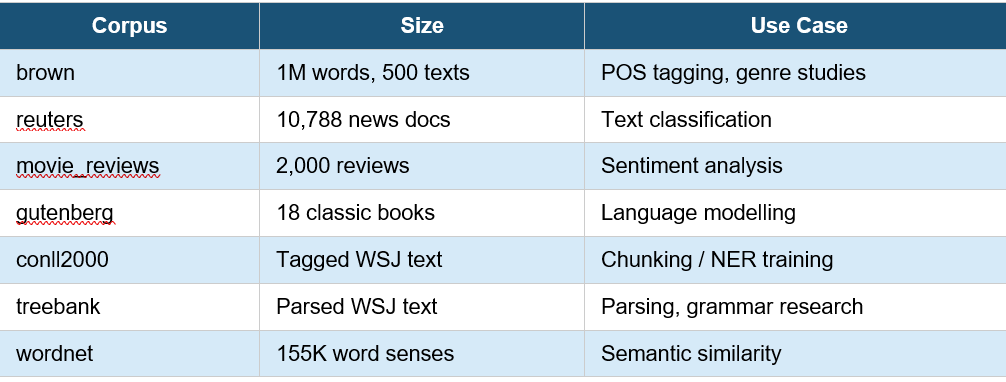

In [ ]:
from nltk.corpus import brown, gutenberg

# Brown corpus — categories
print(brown.categories()[:5])

# Words in a category
news_words = brown.words(categories='news')
print(f'News words: {len(news_words):,}')

# Gutenberg files
print(gutenberg.fileids())

# Read raw text
hamlet = gutenberg.raw('shakespeare-hamlet.txt')
print(hamlet[:200])


['adventure', 'belles_lettres', 'editorial', 'fiction', 'government']
News words: 100,554
['austen-emma.txt', 'austen-persuasion.txt', 'austen-sense.txt', 'bible-kjv.txt', 'blake-poems.txt', 'bryant-stories.txt', 'burgess-busterbrown.txt', 'carroll-alice.txt', 'chesterton-ball.txt', 'chesterton-brown.txt', 'chesterton-thursday.txt', 'edgeworth-parents.txt', 'melville-moby_dick.txt', 'milton-paradise.txt', 'shakespeare-caesar.txt', 'shakespeare-hamlet.txt', 'shakespeare-macbeth.txt', 'whitman-leaves.txt']
[The Tragedie of Hamlet by William Shakespeare 1599]


Actus Primus. Scoena Prima.

Enter Barnardo and Francisco two Centinels.

  Barnardo. Who's there?
  Fran. Nay answer me: Stand & vnfold
your sel


# **`Text cleaning`**
# **C(T)=T-Noise**

In [ ]:
import re
text="AI is transforming the world with technoligy! Vist https://x.com"


# **Removing URLs**

In [ ]:
text=re.sub(r'http\S+','',text)
print(text)

AI is transforming the world with technoligy! Vist 


# **Removing Punctuations**

In [ ]:
text=re.sub(r'[^\w\s]','',text)
print(text)

AI is transforming the world with technoligy Vist 


# **Normalization**
# **N(T)=lower(C(T))**

In [ ]:
text="AI IS AMAZING THING"
norm=text.lower()
print(norm)

ai is amazing thing


# **Tokenization**
# **Tokenization *italicized text* splits text into tokens.**
# **ToK(S)={t1,t2,t3,...,tn)**

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
sen="I love to learning artifical intellgence in this new world!"
tokns=word_tokenize(sen)
print(tokns)

['I', 'love', 'to', 'learning', 'artifical', 'intellgence', 'in', 'this', 'new', 'world', '!']


# **Stopword**
# *Stopwords are common words with little semantic meaning.*
# **S'=S - StopWords**

In [ ]:
from nltk.corpus import stopwords
stop_w=set(stopwords.words('english'))
# print(stop_w)
filter=[word for word in tokns if word not in stop_w]
print(filter)

['I', 'love', 'learning', 'artifical', 'intellgence', 'new', 'world', '!']


# **Subword Tokenization**
# *LLMs use Byte Pair Encoding (BPE) or WordPiece.*
# **(a,b)=argmax(freq(pair))**

In [ ]:
from transformers import AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("bert-base-uncased")
text="I love to learning Natural Language Processing."
tokens=tokenizer.tokenize(text)
print(tokens)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

['i', 'love', 'to', 'learning', 'natural', 'language', 'processing', '.']


# **Vocabulary Mapping**
***Tokens are mapped to numbers.***
# **V : token -> integer**

In [ ]:
encoded=tokenizer.encode("I love NLP")
print(encoded)

[101, 1045, 2293, 17953, 2361, 102]


# **Padding**
*Neural networks require fixed sequence length.*
# **P(x)={x       ∣x∣=L**
# **    {[x, <PAD> ]  ∣x∣<L**

In [ ]:
encoded=tokenizer(
    "I love Natural Language Processing",
    padding="max_length",
    max_length=10,
    truncation=True
)
print(encoded)

{'input_ids': [101, 1045, 2293, 3019, 2653, 6364, 102, 0, 0, 0], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 0, 0, 0]}


# **Attention Mask**
# Attent*ion mask tells model which tokens a*re real.
# **Mi={1  token   0  padding} **

In [ ]:
print(encoded["attention_mask"])

[1, 1, 1, 1, 1, 1, 1, 0, 0, 0]


# **Embedding Conversion**

#Embedding Matrix  :  E ∈ R^ V * d
#V--> vocab size
#d--> embedding dimesion


In [ ]:
import torch
import torch.nn as nn
vocab_size = 100000
embedding_dim = 128
embedding = nn.Embedding(vocab_size, embedding_dim)
input_ids = torch.tensor([1,5,20,7,40])
vector = embedding(input_ids)
print(vector.shape)

torch.Size([5, 128])


**Text preprocessing for LLMs is the computational pipeline that transforms raw natural language into tokenized numerical vectors using cleaning, normalization, tokenization, vocabulary mapping, padding, and embedding techniques for deep learning models.**

# **Positional Encoding**
# *Transformers need token order.*
# **PE(pos,2i)=sin(pos / 10000^2i/d)**

# **PE(pos, 2i + 1)=cos (pos / 10000^2i/d)**

# **pipeline**

Raw Text
   ↓
Cleaning
   ↓
Normalization
   ↓
Tokenization
   ↓
Subword Encoding
   ↓
Vocabulary Mapping
   ↓
Token IDs
   ↓
Padding + Attention Mask
   ↓
Embeddings
   ↓
Transformer Input

In [ ]:
!pip install datasets beautifulsoup4 ftfy regex

# **Data Loading**

In [ ]:
import re
import unicodedata
from bs4 import BeautifulSoup
import ftfy
from datasets import load_dataset


In [ ]:
dataset = load_dataset(
    "wikipedia",
    "20220301.en",
    split="train",
    streaming=True
)
from datasets import load_dataset

data = load_dataset(
    "wikipedia",
    "20220301.en",
    split="train",
    streaming=True
)

print(data)


RuntimeError: Dataset scripts are no longer supported, but found wikipedia.py

# **Step-1**

In [ ]:
!pip install --upgrade datasets

In [ ]:
def fix_encoding(text:str)->str:
  return ftfy.fix_text(text)

# **Step-2**

In [ ]:
def strip_html(text:str)->str:
  soup=BeautifulSoup(text,"html.parser")
  return soup.get_text()

raw="<p>Hello <b>world</b> &amp; friends</p>"
print(strip_html(raw))

Hello world & friends


# **Step-3**

In [ ]:
URL_PATTERN = re.compile(
    r'https?://\S+|www\.\S+',
    re.IGNORECASE
)

def remove_urls(text: str) -> str:
    return URL_PATTERN.sub('', text).strip()
text = "Visit https://en.wikipedia.org for more."
print(remove_urls(text))

Visit  for more.


# **Step-4**

In [ ]:
def normlise_unicode(text:str,form='NFKC')->str:
  return unicodedata.normalize(form,text)
print(normlise_unicode("\ufb011e"))


fi1e


# **Step-5**

In [ ]:
def remove_control_chars(text:str)->str:
  cleaned=[]
  for ch in text:
    cat=unicodedata.category(ch)
    if cat.startswith(('L','N','P','Z','S')):
      cleaned.append(ch)
    elif ch in ('\n', '\t'):
      cleaned.append(ch)
  return ''.join(cleaned)
text = "Hello\x00 World!\nAI\tis amazing\x07"
print(text)

Hello  World!
AI	is amazing


# **Step-6**

In [ ]:
def normlize_whitespace(text:str)->str:
  text=re.sub(r'[ \t]+', ' ', text)   # collapse spaces/tabs
  text = re.sub(r'\n{3,}', '\n\n', text)
  return text.strip()
text = "Hello     world!\t\tThis   is NLP.\n\n\n\nDeep learning    is powerful."
print(text)

Hello     world!		This   is NLP.



Deep learning    is powerful.


# **Complete Pipeline**

In [ ]:
from ftfy import fix_text
from bs4 import BeautifulSoup
import re
import unicodedata

# Example input sentences
sentences = [
    "<p>Hello     world!</p>",
    "Visit https://example.com for AI news.",
    "AI\x00 is amazing!!!",
    "   Machine learning\t\tis powerful   "
]

def fix_encoding(text):
    return fix_text(text)

def strip_html(text):
    return BeautifulSoup(text, "html.parser").get_text()

def remove_urls(text):
    return re.sub(r"http\S+", "", text)

def normalize_unicode(text):
    return unicodedata.normalize("NFKC", text)

def remove_control_chars(text):
    cleaned = []
    for ch in text:
        cat = unicodedata.category(ch)
        if cat.startswith(('L','N','P','Z','S')) or ch in ('\n','\t'):
            cleaned.append(ch)
    return ''.join(cleaned)

def normalize_whitespace(text):
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

def clean_text(text: str) -> str:
    text = fix_encoding(text)
    text = strip_html(text)
    text = remove_urls(text)
    text = normalize_unicode(text)
    text = remove_control_chars(text)
    text = normalize_whitespace(text)
    return text


cleaned = [clean_text(s) for s in sentences if len(clean_text(s)) > 10]

print(f"Clean sentences: {len(cleaned)}")

with open("wiki_clean.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(cleaned))

Clean sentences: 4



# **🧠 Day-2**

# **Vocab building**

---



In [ ]:
with open('wiki_clean.txt',  encoding='utf-8') as f:
    corpus = f.read()
unique_chars=sorted(set(corpus))
print(f"Unique characters: {len(unique_chars)}")
print(f'Vocabulary size: {len(unique_chars)}')
c2i={ch: i for i, ch in enumerate(unique_chars)}
{i: ch for ch, i in c2i.items()}
for ch in list(c2i.items())[:8]:
  print(ch)

Unique characters: 28
Vocabulary size: 28
('\n', 0)
(' ', 1)
('!', 2)
('.', 3)
('A', 4)
('H', 5)
('I', 6)
('M', 7)


In [77]:
!git clone https://github.com/Abhay9889/LLM_Before.git

Cloning into 'LLM_Before'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 30 (delta 1), reused 27 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 7.19 KiB | 7.19 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [78]:
!ls

generate_git_instructions_pdf.py  libs	LLM_Before  README.md  Week-2


In [79]:
%cd LLM_Before

/content/LLM_Before/LLM_Before/LLM_Before


In [81]:
!mkdir Week-2

In [82]:
!mv week2.ipynb Week-2/

mv: cannot stat 'week2.ipynb': No such file or directory
